In [1]:
# ============================================================
# K-Means con DATASET REAL (Wine) — Notebook ilustrativo y visual
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import contingency_matrix

np.random.seed(42)

def title(text):
    print("\n" + "="*len(text))
    print(text)
    print("="*len(text))

# ------------------------------------------------------------
# 1) Cargar dataset real: Wine (3 clases reales, sin usar etiquetas para entrenar)
# ------------------------------------------------------------
title("1) Dataset real: Wine (clustering NO supervisado)")

wine = load_wine(as_frame=True)
df = wine.frame.copy()
df["target_name"] = df["target"].map(lambda i: wine.target_names[i])

display(df.head())
print("N muestras:", df.shape[0], "| N variables:", len(wine.feature_names))
print("Clases reales (solo para comparar al final):", wine.target_names)
X = df[wine.feature_names].values
y_true = df["target"].values


1) Dataset real: Wine (clustering NO supervisado)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


N muestras: 178 | N variables: 13
Clases reales (solo para comparar al final): ['class_0' 'class_1' 'class_2']


In [2]:
# ------------------------------------------------------------
# 2) Exploración rápida: estadísticas + 2 variables (scatter) para hacerse idea
# ------------------------------------------------------------
title("2) Exploración rápida")

display(df[wine.feature_names].describe().T[["mean","std","min","max"]].head(8))



2) Exploración rápida


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66


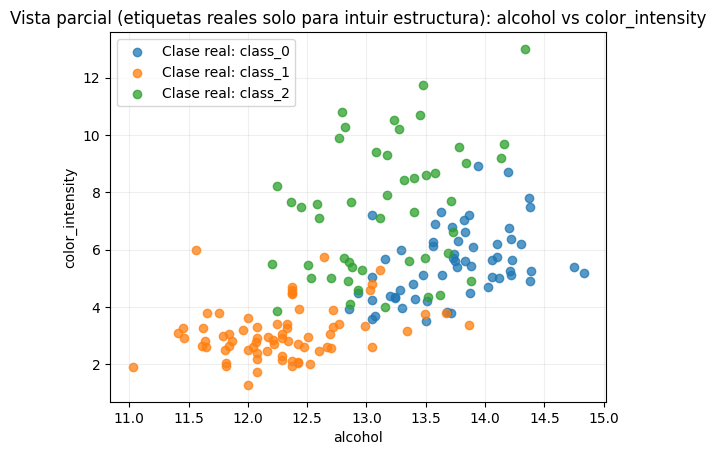

In [3]:

pair = ("alcohol", "color_intensity")
plt.figure()
for c in np.unique(y_true):
    mask = y_true == c
    plt.scatter(df.loc[mask, pair[0]], df.loc[mask, pair[1]], alpha=0.75, label=f"Clase real: {wine.target_names[c]}")
plt.title(f"Vista parcial (etiquetas reales solo para intuir estructura): {pair[0]} vs {pair[1]}")
plt.xlabel(pair[0]); plt.ylabel(pair[1])
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()



In [4]:
# ------------------------------------------------------------
# 3) Estandarización (crucial en K-Means)
# ------------------------------------------------------------
title("3) Estandarización (muy importante en K-Means)")

scaler = StandardScaler()
X_s = scaler.fit_transform(X)




3) Estandarización (muy importante en K-Means)



4) PCA a 2D para visualizar clusters
Varianza explicada por PCA(2): [0.36198848 0.1920749 ] | Total: 0.5540633835693527


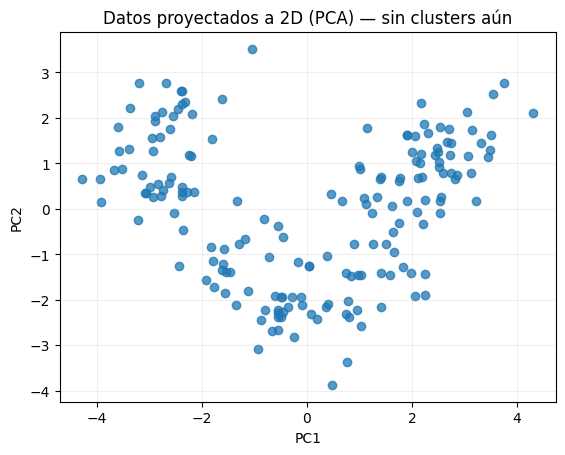

In [5]:
# ------------------------------------------------------------
# 4) PCA 2D para visualización (NO es obligatorio para entrenar, solo para ver)
# ------------------------------------------------------------
title("4) PCA a 2D para visualizar clusters")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_s)

print("Varianza explicada por PCA(2):", pca.explained_variance_ratio_,
      "| Total:", pca.explained_variance_ratio_.sum())

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.75)
plt.title("Datos proyectados a 2D (PCA) — sin clusters aún")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True, alpha=0.2)
plt.show()




5) Elegir número de clusters K (Codo + Silhouette)


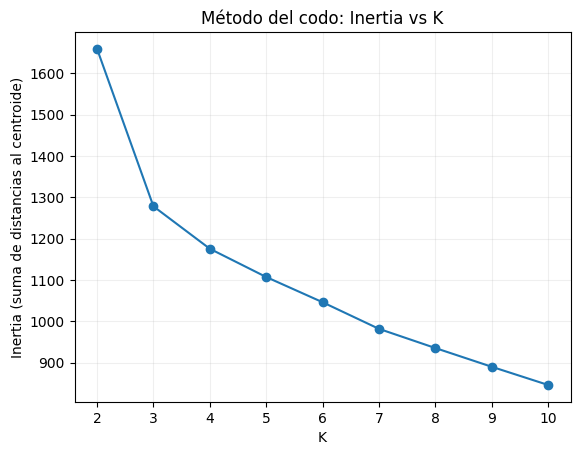

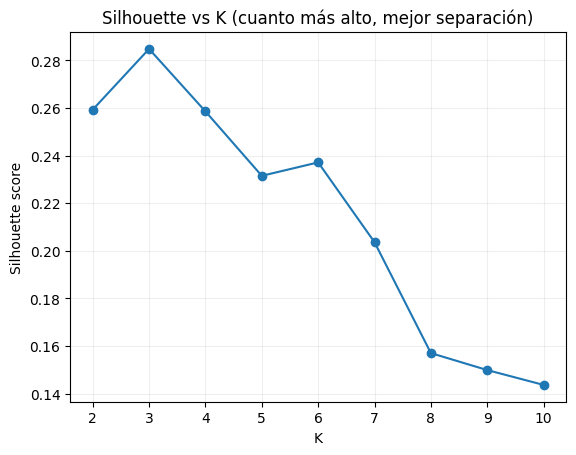

Usaremos K = 3 (ajústalo según tus gráficas)


In [6]:
# ------------------------------------------------------------
# 5) Elegir K: método del codo (Inertia) + Silhouette
# ------------------------------------------------------------
title("5) Elegir número de clusters K (Codo + Silhouette)")

ks = range(2, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_s)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_s, labels))

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.title("Método del codo: Inertia vs K")
plt.xlabel("K")
plt.ylabel("Inertia (suma de distancias al centroide)")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure()
plt.plot(list(ks), sil_scores, marker="o")
plt.title("Silhouette vs K (cuanto más alto, mejor separación)")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.2)
plt.show()

# Recomendación inicial (para Wine suele tener sentido K=3)
K = 3
print(f"Usaremos K = {K} (ajústalo según tus gráficas)")



In [7]:
# ------------------------------------------------------------
# 6) Entrenar K-Means en el espacio REAL (todas las variables estandarizadas)
# ------------------------------------------------------------
title("6) Entrenar K-Means (espacio real: todas las variables estandarizadas)")

kmeans = KMeans(n_clusters=K, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X_s)

print("Inertia final:", kmeans.inertia_)
print("Silhouette final:", silhouette_score(X_s, clusters))




6) Entrenar K-Means (espacio real: todas las variables estandarizadas)
Inertia final: 1277.928488844642
Silhouette final: 0.2848589191898987



7) Visualización clusters (PCA 2D) + centroides


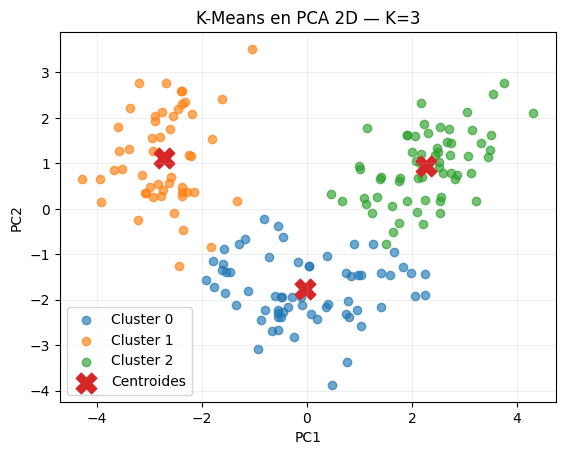

In [8]:
# ------------------------------------------------------------
# 7) Visualización principal: clusters en PCA 2D + centroides proyectados
# ------------------------------------------------------------
title("7) Visualización clusters (PCA 2D) + centroides")

centroids_s = kmeans.cluster_centers_              # centroides en espacio estandarizado (D real)
centroids_pca = pca.transform(centroids_s)         # proyectarlos al plano PCA 2D

plt.figure()
for c in range(K):
    mask = clusters == c
    plt.scatter(X_pca[mask,0], X_pca[mask,1], alpha=0.65, label=f"Cluster {c}")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=220, marker="X", label="Centroides")
plt.title(f"K-Means en PCA 2D — K={K}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()



In [9]:
# ------------------------------------------------------------
# 8) Comparación con clases reales (solo para evaluar, NO supervisado)
# ------------------------------------------------------------
title("8) Comparación con clases reales (solo para interpretación)")

cm = contingency_matrix(y_true, clusters)
print("Matriz de contingencia (filas=clases reales, columnas=clusters):")
display(pd.DataFrame(cm, index=wine.target_names, columns=[f"Cluster {i}" for i in range(K)]))


8) Comparación con clases reales (solo para interpretación)
Matriz de contingencia (filas=clases reales, columnas=clusters):


,Cluster 0,Cluster 1,Cluster 2
class_0,0,0,59
class_1,65,3,3
class_2,0,48,0



9) K-Means 'a mano' en PCA 2D (iteraciones visuales)


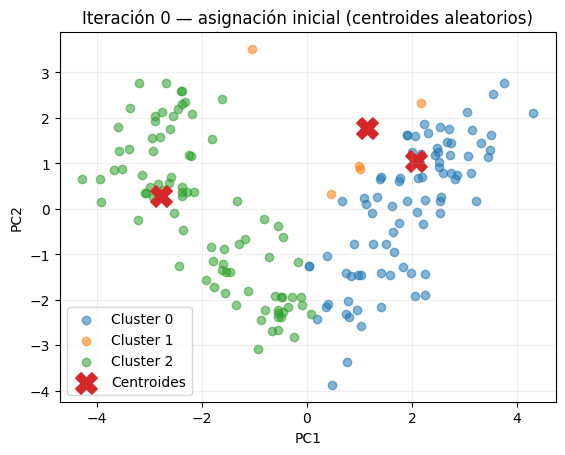

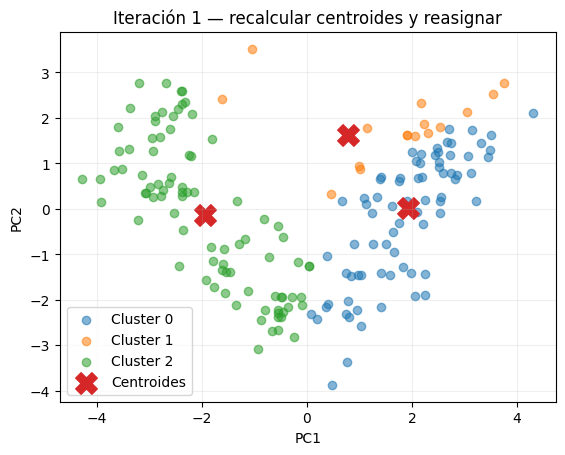

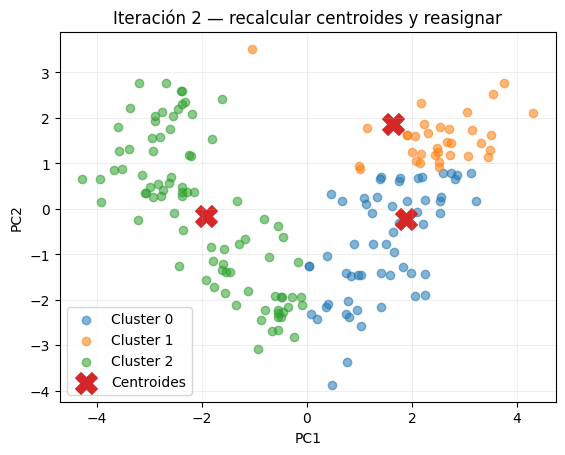

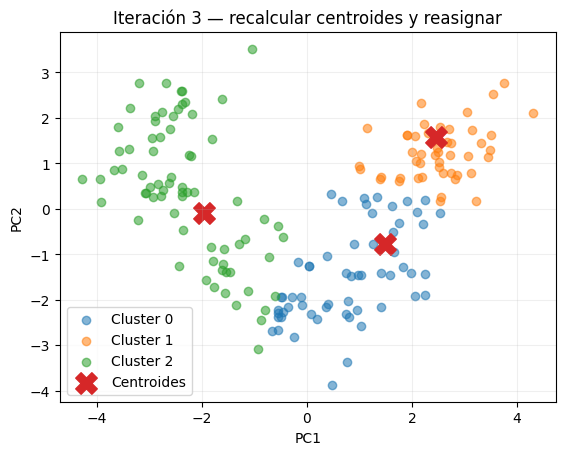

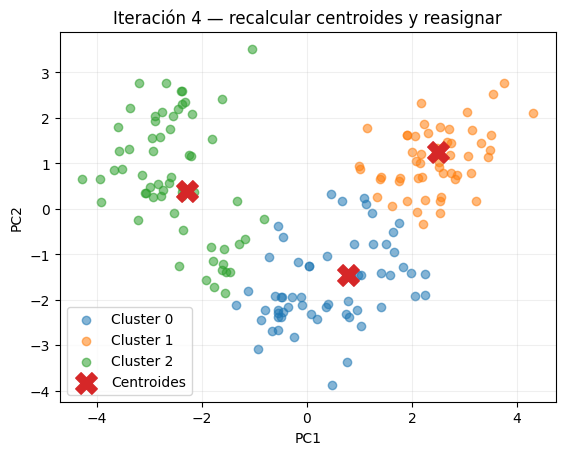

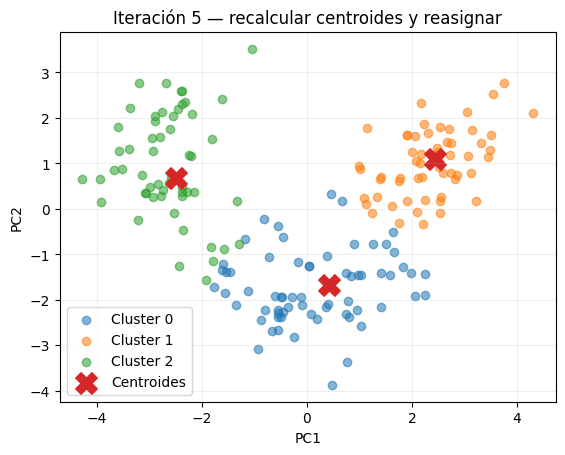

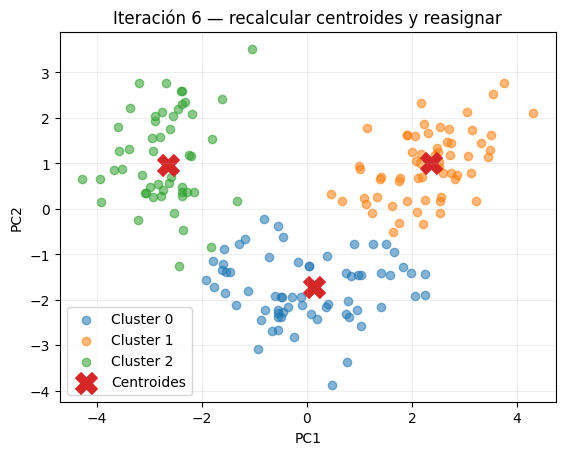

In [10]:
# ------------------------------------------------------------
# 9) “K-Means a mano” en 2D (PCA) para enseñar iteraciones (muy visual)
#    Esto es didáctico: simulamos K-Means en el plano.
# ------------------------------------------------------------
title("9) K-Means 'a mano' en PCA 2D (iteraciones visuales)")

def assign_clusters(X2d, centroids2d):
    # devuelve etiquetas según distancia euclídea al centroide
    dists = np.sqrt(((X2d[:, None, :] - centroids2d[None, :, :]) ** 2).sum(axis=2))
    return np.argmin(dists, axis=1)

def recompute_centroids(X2d, labels, K):
    centroids = np.zeros((K, 2))
    for k in range(K):
        pts = X2d[labels == k]
        # si un cluster queda vacío, re-inicializamos al azar
        if len(pts) == 0:
            centroids[k] = X2d[np.random.randint(0, len(X2d))]
        else:
            centroids[k] = pts.mean(axis=0)
    return centroids

def plot_kmeans_step(X2d, labels, centroids2d, step_title):
    plt.figure()
    for k in range(len(centroids2d)):
        mask = labels == k
        plt.scatter(X2d[mask,0], X2d[mask,1], alpha=0.55, label=f"Cluster {k}")
    plt.scatter(centroids2d[:,0], centroids2d[:,1], s=240, marker="X", label="Centroides")
    plt.title(step_title)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Inicialización aleatoria de centroides en 2D (para ver el proceso)
idx0 = np.random.choice(len(X_pca), size=K, replace=False)
centroids2d = X_pca[idx0].copy()

labels2d = assign_clusters(X_pca, centroids2d)
plot_kmeans_step(X_pca, labels2d, centroids2d, "Iteración 0 — asignación inicial (centroides aleatorios)")

max_iters = 6
for it in range(1, max_iters+1):
    centroids2d_new = recompute_centroids(X_pca, labels2d, K)
    labels2d_new = assign_clusters(X_pca, centroids2d_new)

    plot_kmeans_step(X_pca, labels2d_new, centroids2d_new, f"Iteración {it} — recalcular centroides y reasignar")

    # parada si no cambia nada
    if np.all(labels2d_new == labels2d):
        print(f"Convergencia: no cambian etiquetas en iteración {it}.")
        break

    labels2d, centroids2d = labels2d_new, centroids2d_new


10) BONUS: Interpretación de clusters (perfil medio por variable)


cluster,0,1,2
alcohol,12.250923,13.134118,13.676774
malic_acid,1.897385,3.307255,1.997903
ash,2.231231,2.417647,2.466290
alcalinity_of_ash,20.063077,21.241176,17.462903
magnesium,92.738462,98.666667,107.967742
total_phenols,2.247692,1.683922,2.847581
flavanoids,2.050000,0.818824,3.003226
nonflavanoid_phenols,0.357692,0.451961,0.292097
proanthocyanins,1.624154,1.145882,1.922097
color_intensity,2.973077,7.234706,5.453548


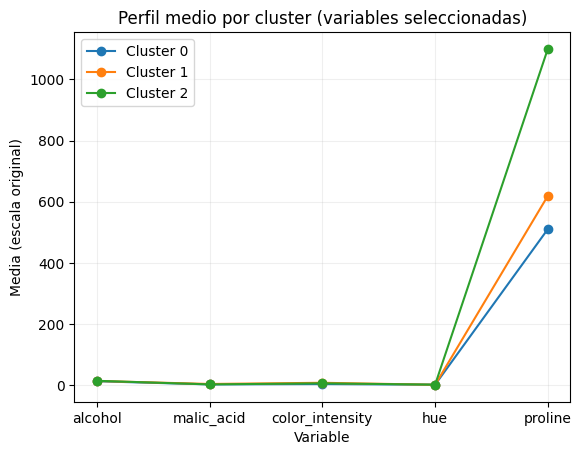

In [11]:
# ------------------------------------------------------------
# 10) BONUS: Interpretar clusters con variables originales (perfil medio)
# ------------------------------------------------------------
title("10) BONUS: Interpretación de clusters (perfil medio por variable)")

df_clusters = df[wine.feature_names].copy()
df_clusters["cluster"] = clusters

means = df_clusters.groupby("cluster").mean().T
display(means.head(12))

# Gráfico de unas pocas variables para comparar perfiles (selección simple)
features_to_plot = ["alcohol", "malic_acid", "color_intensity", "hue", "proline"]
plt.figure()
for cl in range(K):
    plt.plot(features_to_plot, means[cl].loc[features_to_plot], marker="o", label=f"Cluster {cl}")
plt.title("Perfil medio por cluster (variables seleccionadas)")
plt.xlabel("Variable")
plt.ylabel("Media (escala original)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


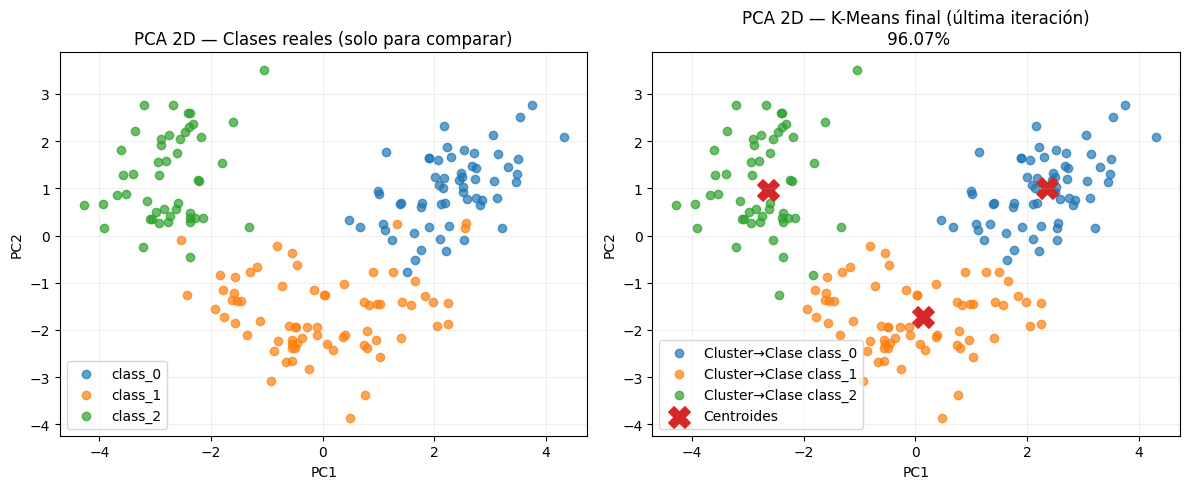

In [ ]:

final_labels2d = labels2d
final_centroids2d = centroids2d
try:
    from scipy.optimize import linear_sum_assignment
    K = len(np.unique(final_labels2d))
    contingency = np.zeros((len(np.unique(y_true)), K), dtype=int)
    for i in range(len(y_true)):
        contingency[y_true[i], final_labels2d[i]] += 1
    cost = contingency.max() - contingency
    row_ind, col_ind = linear_sum_assignment(cost)

    mapping = {col: row for row, col in zip(row_ind, col_ind)}  # cluster -> clase real
    aligned_labels2d = np.array([mapping[c] for c in final_labels2d])

except Exception:
    K = len(np.unique(final_labels2d))
    contingency = np.zeros((len(np.unique(y_true)), K), dtype=int)
    for i in range(len(y_true)):
        contingency[y_true[i], final_labels2d[i]] += 1
    mapping = {c: np.argmax(contingency[:, c]) for c in range(K)}
    aligned_labels2d = np.array([mapping[c] for c in final_labels2d])
agreement = (aligned_labels2d == y_true).mean()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for c in np.unique(y_true):
    mask = y_true == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.7, label=wine.target_names[c])
plt.title("PCA 2D — Clases reales (solo para comparar)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.subplot(1, 2, 2)
for c in np.unique(aligned_labels2d):
    mask = aligned_labels2d == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.7, label=f"Cluster→Clase {wine.target_names[c]}")
plt.scatter(final_centroids2d[:, 0], final_centroids2d[:, 1], s=240, marker="X", label="Centroides")
plt.title(f"PCA 2D — K-Means final (última iteración)\n {agreement:.2%}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


